# Pertemuan 6 — CIFAR-10 Custom CNN Feature Maps → SVM (Testing)

Notebook testing untuk model yang disimpan dalam **satu file HDF5**:

```text
cifar10_cnn_svm_model.h5
```

File tersebut memuat:
- custom CNN architecture + weights,
- serialized `StandardScaler + RBF-SVM` pipeline,
- metadata feature layer.

Testing hanya menggunakan **official CIFAR-10 test split** dan tidak melakukan training atau tuning.

In [1]:
import os
import random
import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 23092026

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf

# Hindari TensorFlow langsung mengalokasikan hampir seluruh VRAM.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("GPU:", gpus)

tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

I0000 00:00:1790733199.156811   82019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790733199.193379   82019 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790733200.261340   82019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Unseen CIFAR-10 Test Set

In [2]:
_, (X_test, y_test) = cifar10.load_data()

y_test = y_test.flatten()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (10000, 32, 32, 3)
y_test: (10000,)


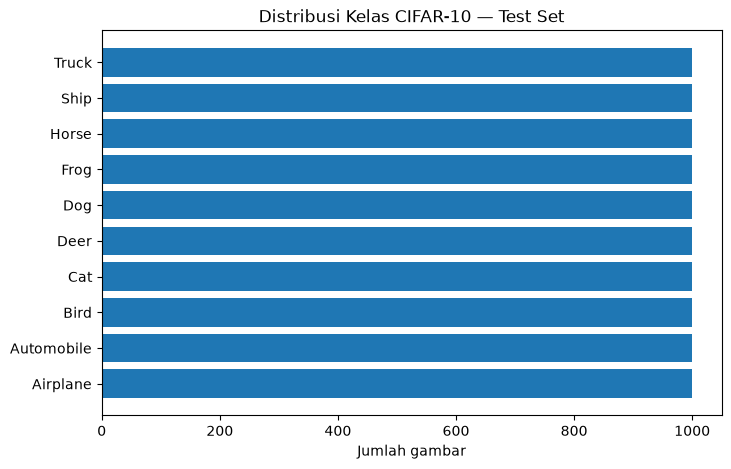

In [3]:
classes, counts = np.unique(
    y_test,
    return_counts=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    classes_name,
    counts
)
plt.title(
    "Distribusi Kelas CIFAR-10 — Test Set"
)
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Preprocessing

Harus identik dengan preprocessing training.

In [4]:
X_test = X_test.astype(
    "float32"
) / 255.0

y_cat_test = to_categorical(
    y_test,
    10
)

print("X_test:", X_test.shape)
print("y_cat_test:", y_cat_test.shape)

X_test: (10000, 32, 32, 3)
y_cat_test: (10000, 10)


## 3. Load Custom CNN dan SVM

In [5]:
MODEL_PATH = "cifar10_cnn_svm_model.h5"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"{MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

# Load CNN dari bagian Keras HDF5.
# compile=False cukup karena testing memakai predict(), bukan training.
tf.keras.backend.clear_session()

cnn_model = load_model(
    MODEL_PATH,
    compile=False
)

# Load sklearn SVM Pipeline dari dataset tambahan dalam HDF5 yang sama.
with h5py.File(MODEL_PATH, "r") as h5_file:
    if "svm_pipeline_pickle" not in h5_file:
        raise KeyError(
            "Dataset 'svm_pipeline_pickle' tidak ditemukan dalam file H5. "
            "Pastikan cell penyimpanan akhir pada notebook training sudah dijalankan."
        )

    svm_bytes = h5_file[
        "svm_pipeline_pickle"
    ][()].tobytes()

    svm_model = pickle.loads(
        svm_bytes
    )

    svm_feature_layer = h5_file.attrs.get(
        "svm_feature_layer",
        "svm_features"
    )

print("CNN dan SVM berhasil dimuat dari:")
print(MODEL_PATH)

cnn_model.summary()

print("\nSVM:")
print(svm_model)

print("\nFeature layer:")
print(svm_feature_layer)

I0000 00:00:1790733202.908221   82019 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3644 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


CNN dan SVM berhasil dimuat dari:
cifar10_cnn_svm_model.h5


Model: "custom_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 4, 4, 512)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map (Conv2D)            │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_map_bn                  │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,962,890 (18.93 MB)

 Trainable params: 4,958,026 (18.91 MB)

 Non-trainable params: 4,864 (19.00 KB)


SVM:
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, cache_size=4096))])

Feature layer:
svm_features


# 4. Feature Map Extraction pada Test Image

Sama seperti tahap feature-map extraction saat training, tetapi sekarang menggunakan gambar yang benar-benar unseen.

I0000 00:00:1790733204.289131   82113 service.cc:153] XLA service 0x7d5f5c045640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790733204.289160   82113 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790733204.317087   82113 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790733204.411577   82113 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790733207.108048   82113 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


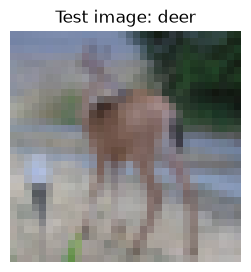

conv1_2: (1, 32, 32, 64)


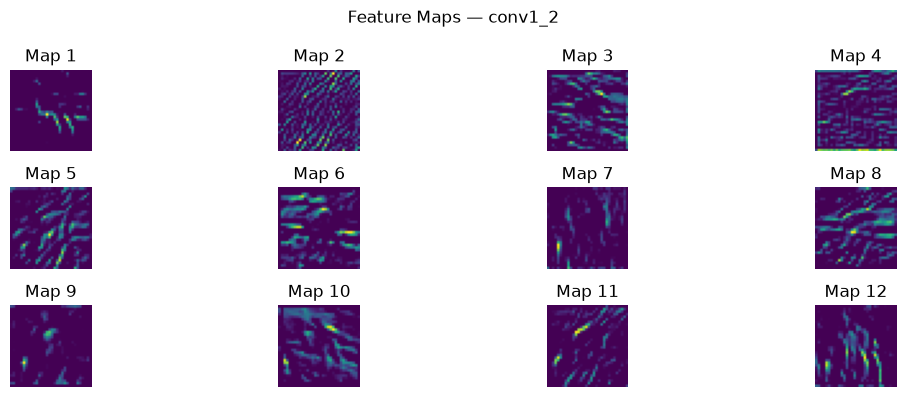

conv2_2: (1, 16, 16, 128)


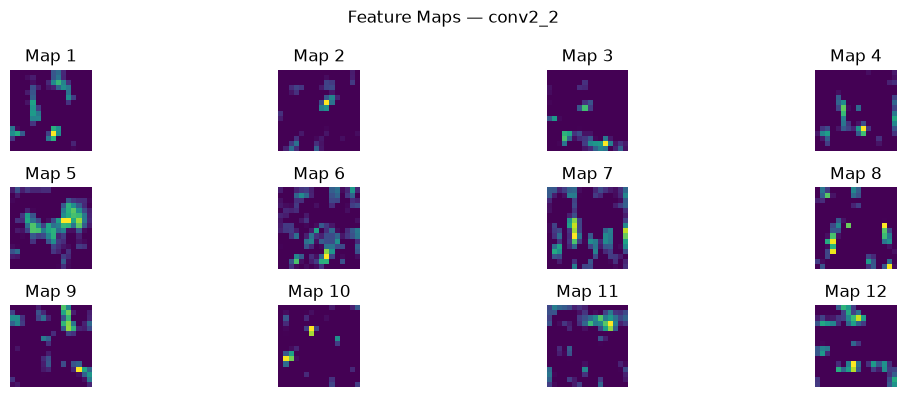

conv3_2: (1, 8, 8, 256)


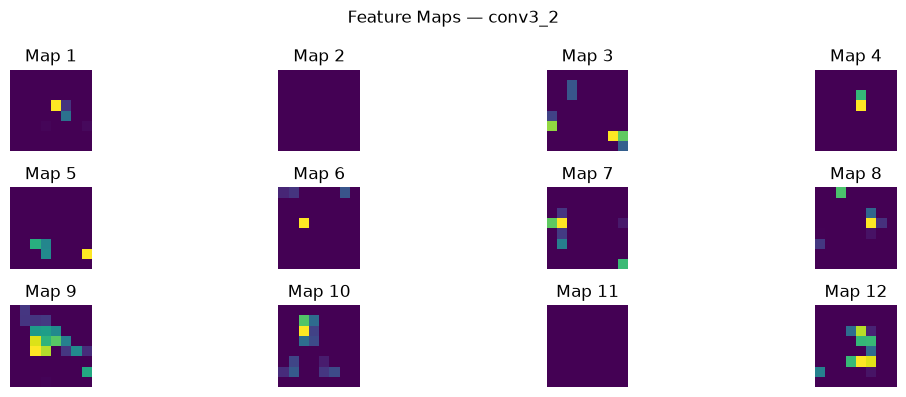

feature_map: (1, 4, 4, 512)


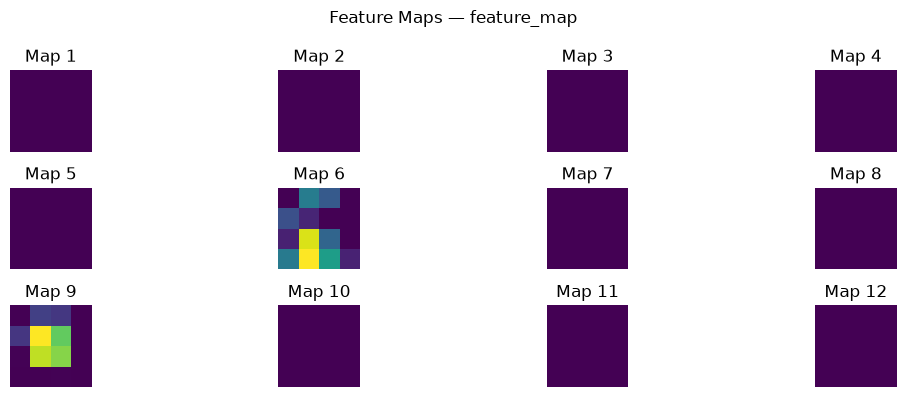

In [6]:
FEATURE_MAP_LAYERS = [
    "conv1_2",
    "conv2_2",
    "conv3_2",
    "feature_map"
]

feature_map_model = Model(
    inputs=cnn_model.input,
    outputs=[
        cnn_model.get_layer(name).output
        for name in FEATURE_MAP_LAYERS
    ],
    name="feature_map_extractor"
)

sample_index = 100
sample_image = X_test[
    sample_index:sample_index + 1
]

feature_maps = feature_map_model.predict(
    sample_image,
    verbose=0
)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(
    f"Test image: "
    f"{labels[y_test[sample_index]]}"
)
plt.axis("off")
plt.show()

for layer_name, fmap in zip(
    FEATURE_MAP_LAYERS,
    feature_maps
):
    n_show = min(
        12,
        fmap.shape[-1]
    )

    print(
        f"{layer_name}: {fmap.shape}"
    )

    plt.figure(figsize=(12, 4))

    for i in range(n_show):
        plt.subplot(
            3,
            4,
            i + 1
        )
        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )
        plt.title(
            f"Map {i + 1}"
        )
        plt.axis("off")

    plt.suptitle(
        f"Feature Maps — {layer_name}"
    )
    plt.tight_layout()
    plt.show()

## 5. Baseline: Evaluasi CNN Softmax

Ini hanya pembanding.

Hasil utama tugas tetap **CNN feature extraction + SVM**.

In [7]:
cnn_probability = cnn_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

cnn_prediction = np.argmax(
    cnn_probability,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    cnn_prediction
)

print(
    f"CNN test accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
CNN test accuracy: 92.52%


# 6. Extract CNN Features untuk Seluruh Test Set

SVM menerima output layer `svm_features`, yaitu vector yang berasal dari high-level convolutional feature maps setelah Global Average Pooling.

In [8]:
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer(
        svm_feature_layer
    ).output,
    name="cnn_feature_extractor"
)

X_test_features = feature_extractor.predict(
    X_test,
    batch_size=128,
    verbose=1
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Extracted feature shape:",
    X_test_features.shape
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Original test shape: (10000, 32, 32, 3)
Extracted feature shape: (10000, 512)


# 7. Klasifikasi SVM

In [9]:
svm_prediction = svm_model.predict(
    X_test_features
)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print("=" * 65)
print("HASIL FINAL")
print("=" * 65)

print(
    f"Custom CNN : "
    f"{cnn_accuracy * 100:.2f}%"
)

print(
    f"CNN Feature + SVM Accuracy  : "
    f"{svm_accuracy * 100:.2f}%"
)

print("=" * 65)

if svm_accuracy > 0.86:
    print(
        "TARGET TERCAPAI: "
        "akurasi SVM > 86%"
    )
else:
    print(
        "TARGET BELUM TERCAPAI: "
        "akurasi SVM masih <= 86%"
    )

HASIL FINAL
Custom CNN : 92.52%
CNN Feature + SVM Accuracy  : 92.96%
TARGET TERCAPAI: akurasi SVM > 86%


## 8. Classification Report SVM

In [10]:
print(
    classification_report(
        y_test,
        svm_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9388    0.9360    0.9374      1000
  automobile     0.9698    0.9640    0.9669      1000
        bird     0.9191    0.8980    0.9084      1000
         cat     0.8395    0.8630    0.8511      1000
        deer     0.9302    0.9330    0.9316      1000
         dog     0.8965    0.8920    0.8942      1000
        frog     0.9416    0.9510    0.9463      1000
       horse     0.9604    0.9450    0.9526      1000
        ship     0.9609    0.9590    0.9600      1000
       truck     0.9418    0.9550    0.9484      1000

    accuracy                         0.9296     10000
   macro avg     0.9299    0.9296    0.9297     10000
weighted avg     0.9299    0.9296    0.9297     10000



## 9. Perbandingan CNN vs SVM

In [11]:
comparison = pd.DataFrame({
    "Classifier": [
        "CNN Softmax",
        "SVM on CNN Features"
    ],
    "Test Accuracy": [
        cnn_accuracy,
        svm_accuracy
    ]
})

display(comparison)

,Classifier,Test Accuracy
0,CNN Softmax,0.9252
1,SVM on CNN Features,0.9296


## 10. Confusion Matrix — SVM

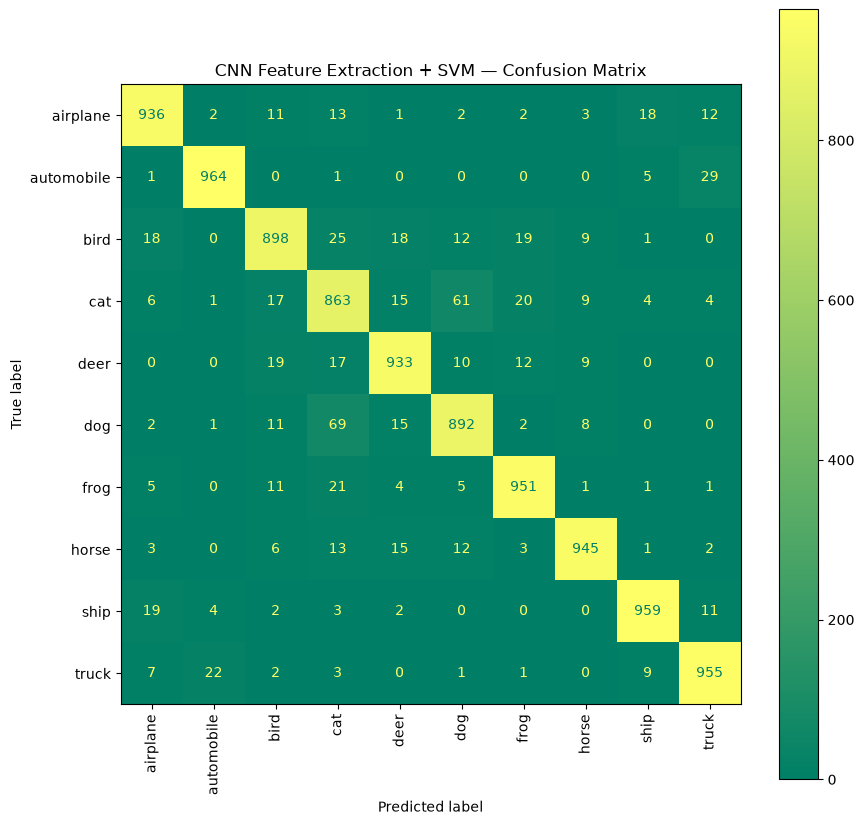

In [12]:
cm = confusion_matrix(
    y_test,
    svm_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical",
    cmap="summer"
)

plt.title(
    "CNN Feature Extraction + SVM "
    "— Confusion Matrix"
)

plt.show()

## 11. Beberapa Hasil Prediksi

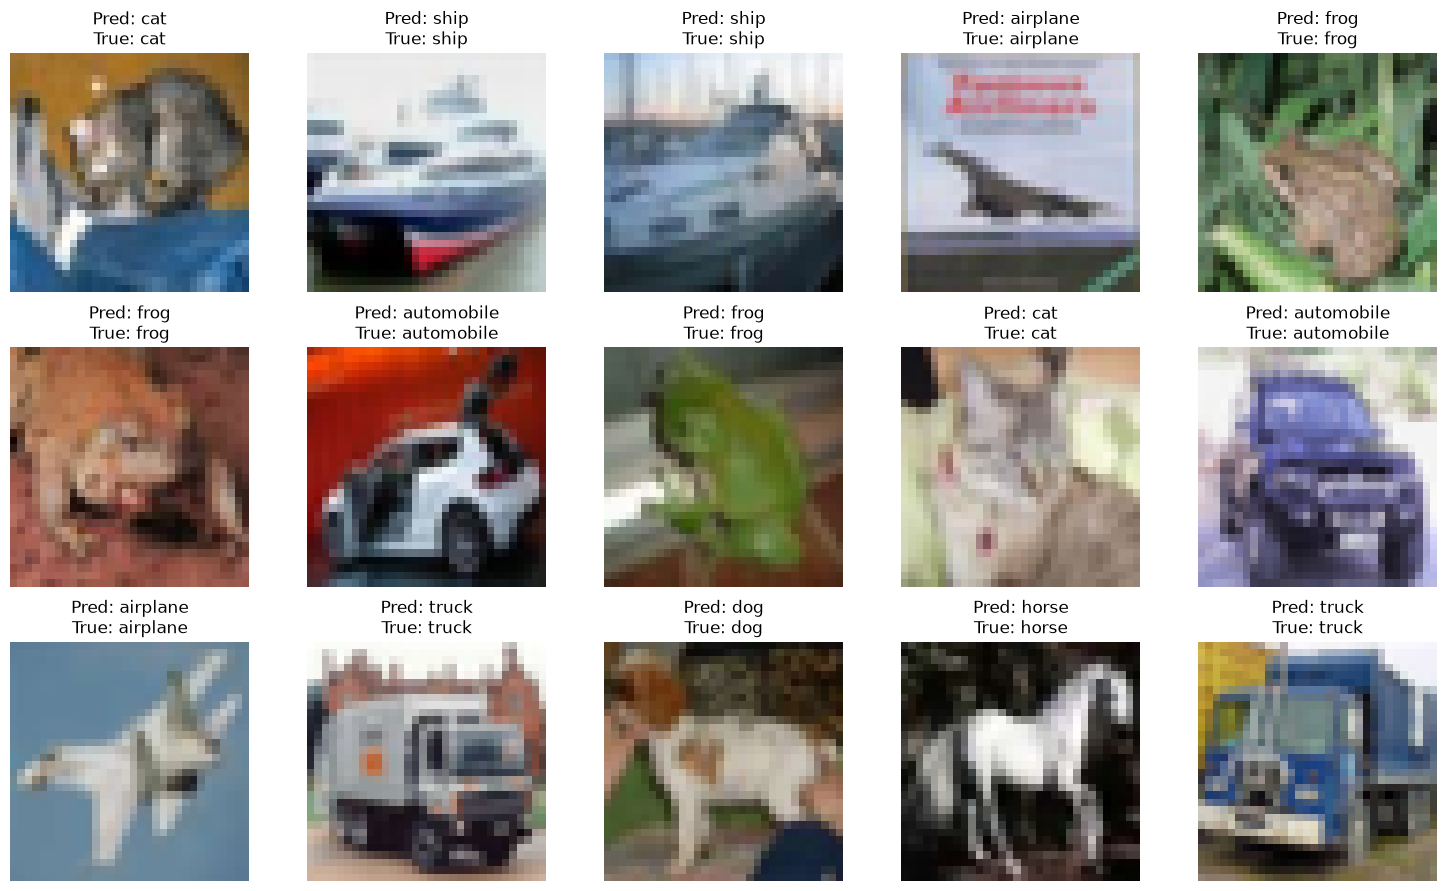

In [13]:
num_rows = 3
num_cols = 5
num_images = (
    num_rows * num_cols
)

plt.figure(figsize=(15, 9))

for i in range(num_images):
    plt.subplot(
        num_rows,
        num_cols,
        i + 1
    )

    plt.imshow(
        X_test[i]
    )

    predicted = int(
        svm_prediction[i]
    )

    actual = int(
        y_test[i]
    )

    plt.title(
        f"Pred: {labels[predicted]}\n"
        f"True: {labels[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()